In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
students = pd.read_csv("students.csv")
companies = pd.read_csv("companies.csv")
applications = pd.read_csv("applications.csv")
interviews = pd.read_csv("interviews.csv")
offers = pd.read_csv("offers.csv")

In [4]:
print("Students:", students.shape)
print("Companies:", companies.shape)
print("Applications:", applications.shape)
print("Interviews:", interviews.shape)
print("Offers:", offers.shape)

Students: (500, 6)
Companies: (99, 5)
Applications: (3000, 6)
Interviews: (1500, 5)
Offers: (800, 5)


In [5]:
print("Students")
print(students.isnull().sum())

print("\nCompanies")
print(companies.isnull().sum())

print("\nApplications")
print(applications.isnull().sum())

print("\nInterviews")
print(interviews.isnull().sum())

print("\nOffers")
print(offers.isnull().sum())

Students
Student_ID         0
Name               0
College            0
Branch             0
CGPA               0
Graduation_Year    0
dtype: int64

Companies
Company_ID         0
Company_Name       0
Industry           0
Location           0
Internship_Type    0
dtype: int64

Applications
Application_ID    0
Student_ID        0
Company_ID        0
Applied_Date      0
Source            0
Status            0
dtype: int64

Interviews
Interview_ID      0
Application_ID    0
Round             0
Interview_Date    0
Result            0
dtype: int64

Offers
Offer_ID          0
Application_ID    0
Offer_Date        0
Stipend           0
Accepted          0
dtype: int64


In [6]:
print("Students:", students.duplicated().sum())
print("Companies:", companies.duplicated().sum())
print("Applications:", applications.duplicated().sum())
print("Interviews:", interviews.duplicated().sum())
print("Offers:", offers.duplicated().sum())

Students: 0
Companies: 0
Applications: 0
Interviews: 0
Offers: 0


In [7]:
students.drop_duplicates(inplace=True)
companies.drop_duplicates(inplace=True)
applications.drop_duplicates(inplace=True)
interviews.drop_duplicates(inplace=True)
offers.drop_duplicates(inplace=True)

students.dropna(inplace=True)
companies.dropna(inplace=True)
applications.dropna(inplace=True)
interviews.dropna(inplace=True)
offers.dropna(inplace=True)

print("Cleaning Completed!")

Cleaning Completed!


In [8]:
print(students.shape)
print(companies.shape)
print(applications.shape)
print(interviews.shape)
print(offers.shape)

(500, 6)
(99, 5)
(3000, 6)
(1500, 5)
(800, 5)


In [9]:
merged = applications.merge(
    students,
    on="Student_ID",
    how="left"
)

merged = merged.merge(
    companies,
    on="Company_ID",
    how="left"
)

merged = merged.merge(
    offers,
    on="Application_ID",
    how="left"
)

merged = merged.merge(
    interviews,
    on="Application_ID",
    how="left"
)

print(merged.shape)
merged.head()

(3453, 23)


,Application_ID,Student_ID,Company_ID,Applied_Date,Source,Status,Name,College,Branch,CGPA,...,Location,Internship_Type,Offer_ID,Offer_Date,Stipend,Accepted,Interview_ID,Round,Interview_Date,Result
0,A0001,S293,C005,2025-08-08,Company Website,Rejected,Krisha Desai,Nirma University,AI & DS,9.67,...,Bangalore,AI/ML,O0249,2025-11-06,20000.0,Yes,I0356,HR Round,2025-05-25,Pass
1,A0001,S293,C005,2025-08-08,Company Website,Rejected,Krisha Desai,Nirma University,AI & DS,9.67,...,Bangalore,AI/ML,O0249,2025-11-06,20000.0,Yes,I0395,Technical Round,2025-03-18,Pass
2,A0001,S293,C005,2025-08-08,Company Website,Rejected,Krisha Desai,Nirma University,AI & DS,9.67,...,Bangalore,AI/ML,O0569,2025-03-04,5000.0,No,I0356,HR Round,2025-05-25,Pass
3,A0001,S293,C005,2025-08-08,Company Website,Rejected,Krisha Desai,Nirma University,AI & DS,9.67,...,Bangalore,AI/ML,O0569,2025-03-04,5000.0,No,I0395,Technical Round,2025-03-18,Pass
4,A0002,S008,C027,2025-08-25,Company Website,Interview,Vivaan Mehta,MBIT,Electrical,7.11,...,Bangalore,IoT,NaN,NaN,NaN,NaN,I0551,Manager Round,2025-03-06,Fail


In [10]:
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 3453 entries, 0 to 3452
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Application_ID   3453 non-null   str    
 1   Student_ID       3453 non-null   str    
 2   Company_ID       3453 non-null   str    
 3   Applied_Date     3453 non-null   str    
 4   Source           3453 non-null   str    
 5   Status           3453 non-null   str    
 6   Name             3453 non-null   str    
 7   College          3453 non-null   str    
 8   Branch           3453 non-null   str    
 9   CGPA             3453 non-null   float64
 10  Graduation_Year  3453 non-null   int64  
 11  Company_Name     3419 non-null   str    
 12  Industry         3419 non-null   str    
 13  Location         3419 non-null   str    
 14  Internship_Type  3419 non-null   str    
 15  Offer_ID         887 non-null    str    
 16  Offer_Date       887 non-null    str    
 17  Stipend          887 non-

In [11]:
merged.describe(include="all")

,Application_ID,Student_ID,Company_ID,Applied_Date,Source,Status,Name,College,Branch,CGPA,...,Location,Internship_Type,Offer_ID,Offer_Date,Stipend,Accepted,Interview_ID,Round,Interview_Date,Result
count,3453,3453,3453,3453,3453,3453,3453,3453,3453,3453.000000,...,3419,3419,887,887,887.000000,887,1554,1554,1554,1554
unique,3000,498,100,366,5,5,50,6,6,NaN,...,9,7,800,324,NaN,2,1500,4,360,2
top,A2019,S216,C096,2025-08-05,Internshala,Applied,Nensi Desai,PDEU,Mechanical,NaN,...,Bangalore,Data Analytics,O0072,2025-02-19,NaN,No,I0858,Technical Round,2025-03-20,Pass
freq,9,18,53,23,737,722,120,613,665,NaN,...,573,565,3,10,NaN,449,3,435,13,778
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.954049,...,NaN,NaN,NaN,NaN,13520.856821,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.068683,...,NaN,NaN,NaN,NaN,6670.862838,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.010000,...,NaN,NaN,NaN,NaN,5000.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.090000,...,NaN,NaN,NaN,NaN,8000.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.990000,...,NaN,NaN,NaN,NaN,12000.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.860000,...,NaN,NaN,NaN,NaN,20000.000000,NaN,NaN,NaN,NaN,NaN


In [12]:
print(applications.columns.tolist())

['Application_ID', 'Student_ID', 'Company_ID', 'Applied_Date', 'Source', 'Status']


In [13]:
print(students.columns.tolist())


['Student_ID', 'Name', 'College', 'Branch', 'CGPA', 'Graduation_Year']


In [14]:
print(companies.columns.tolist())


['Company_ID', 'Company_Name', 'Industry', 'Location', 'Internship_Type']


In [15]:
print(interviews.columns.tolist())
print(offers.columns.tolist())

['Interview_ID', 'Application_ID', 'Round', 'Interview_Date', 'Result']
['Offer_ID', 'Application_ID', 'Offer_Date', 'Stipend', 'Accepted']


In [16]:
print(merged.shape)

(3453, 23)


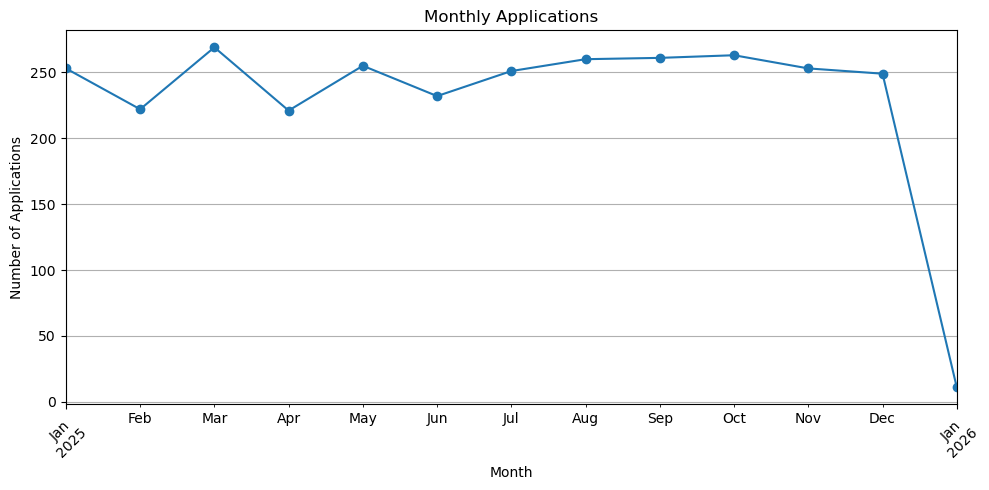

In [17]:
import matplotlib.pyplot as plt

applications['Applied_Date'] = pd.to_datetime(applications['Applied_Date'])

monthly = applications.groupby(
    applications['Applied_Date'].dt.to_period('M')
).size()

plt.figure(figsize=(10,5))
monthly.plot(marker='o')

plt.title("Monthly Applications")
plt.xlabel("Month")
plt.ylabel("Number of Applications")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

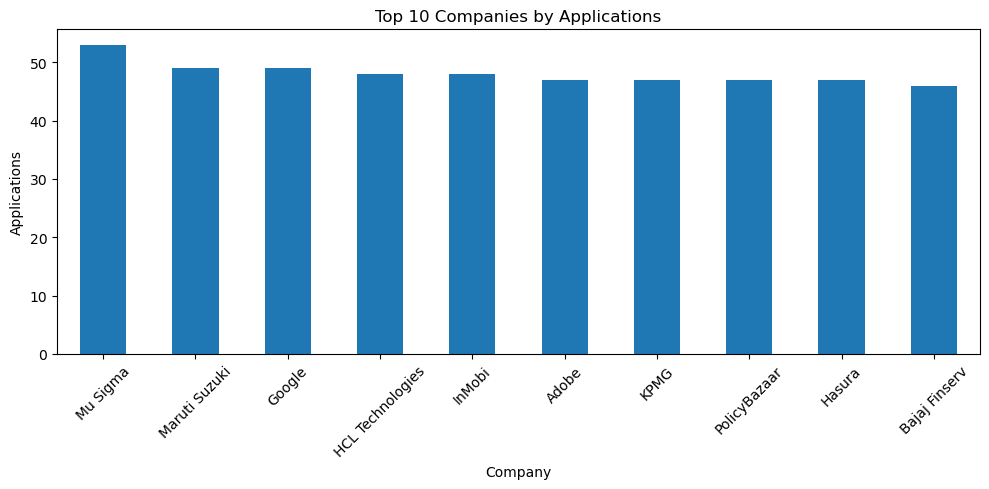

In [18]:
top_companies = merged['Company_Name'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_companies.plot(kind='bar')

plt.title("Top 10 Companies by Applications")
plt.xlabel("Company")
plt.ylabel("Applications")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

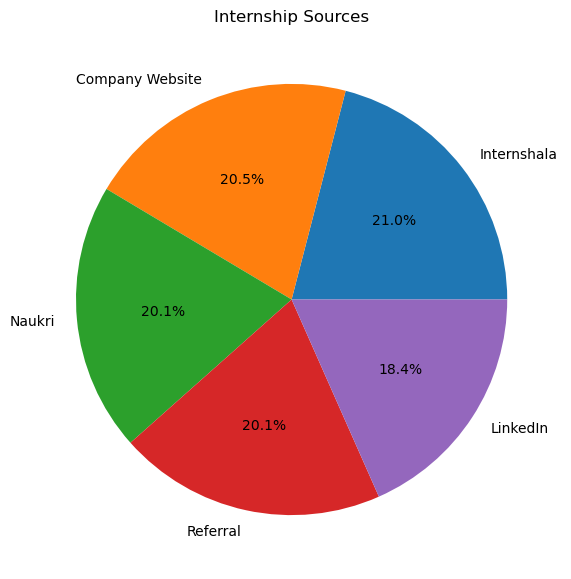

In [19]:
source = applications['Source'].value_counts()

plt.figure(figsize=(7,7))
source.plot(kind='pie', autopct='%1.1f%%')

plt.title("Internship Sources")
plt.ylabel("")

plt.show()

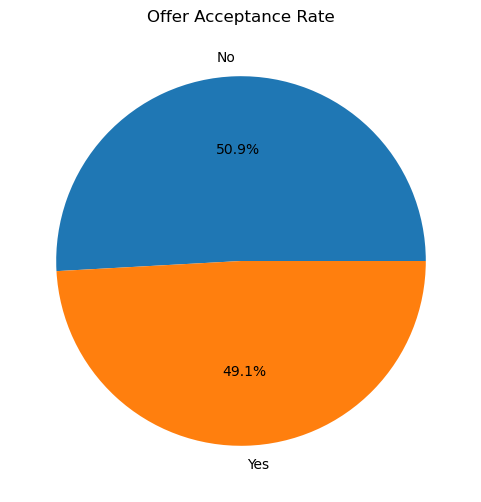

In [20]:
offer = offers['Accepted'].value_counts()

plt.figure(figsize=(6,6))
offer.plot(kind='pie', autopct='%1.1f%%')

plt.title("Offer Acceptance Rate")
plt.ylabel("")

plt.show()

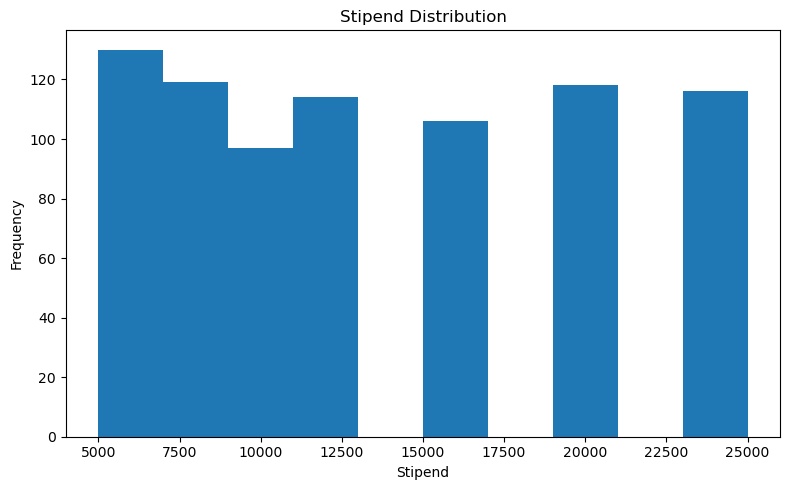

In [21]:
plt.figure(figsize=(8,5))

plt.hist(offers['Stipend'], bins=10)

plt.title("Stipend Distribution")
plt.xlabel("Stipend")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()